TASK 4: Disease Prediction from Medical Data

Objective: Predict the possibility of diseases based on patient data.

Approach: Apply classification techniques to structured medical datasets.

Key Features:

Use features like symptoms, age, blood test results, etc.

Algorithms: SVM, Logistic Regression, Random Forest, XGBoost.

Datasets: Heart disease, Diabetes, Breast Cancer (UCI ML Repository).

In [ ]:
# Step-1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Step-2 Install the dataset package
!pip install ucimlrepo

In [ ]:
# Step-3 Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Step-4 Download the Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [ ]:
# Step-5 Get features and target
X = heart_disease.data.features
y = heart_disease.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303, 1)


In [ ]:
# Step-6 Display the dataset
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [ ]:
# Step-7 Check for missing values
print(X.isnull().sum())
# also check
print("Total missing values:", X.isnull().sum().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64
Total missing values: 6


In [ ]:
# Step-8 Check the target
print(y.head())
print("\nTarget values:")
print(y.value_counts())
# The original UCI target (num) ranges from 0 to 4; for the standard binary classification task, 0 means absence and 1–4 mean presence of heart disease.
#We therefore convert it to a binary target:
y = (y > 0).astype(int)

print(y.value_counts())


   num
0    0
1    2
2    1
3    0
4    0

Target values:
num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64
num
0      164
1      139
Name: count, dtype: int64


In [ ]:
# Step-9 Handle missing values
X = X.copy()

X = X.fillna(X.median(numeric_only=True))

print("Missing values remaining:")
print(X.isnull().sum())

Missing values remaining:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


In [ ]:
# Step-10 Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.values.ravel(),
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [ ]:

from sklearn.preprocessing import StandardScaler

print("StandardScaler imported successfully!")


StandardScaler imported successfully!


In [ ]:
#  Step 11 - Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [ ]:
# Step-12 Train Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [ ]:
# Step-13 Make predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

print(y_pred_logistic[:20])

[0 1 0 0 1 0 0 0 1 0 1 0 0 1 1 1 1 0 1 1]


In [ ]:
# Step-14 Calculate accuracy
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print(
    "Logistic Regression Accuracy:",
    logistic_accuracy
)

print(
    "Accuracy (%):",
    logistic_accuracy * 100
)


Logistic Regression Accuracy: 0.8688524590163934
Accuracy (%): 86.88524590163934


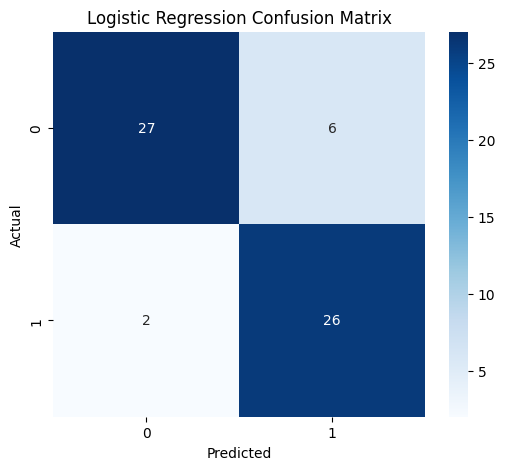

In [ ]:
# Step-15 Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
# STEP 16 — Classification Report
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [ ]:
# STEP 17 — Train SVM
svm_model = SVC(
    kernel="rbf",
    probability=True
)

svm_model.fit(
    X_train_scaled,
    y_train
)

print("SVM trained successfully!")

SVM trained successfully!


In [ ]:
# Predict
y_pred_svm = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print("SVM Accuracy:", svm_accuracy)
print("SVM Accuracy (%):", svm_accuracy * 100)

SVM Accuracy: 0.8524590163934426
SVM Accuracy (%): 85.24590163934425


In [ ]:
# STEP 18 — Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")
# Notice that we use:
X_train
# rather than:
X_train_scaled
# Predict:
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

Random Forest trained successfully!
Random Forest Accuracy: 0.8852459016393442
Random Forest Accuracy (%): 88.52459016393442


In [ ]:
# STEP 19 — Compare the models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        svm_accuracy,
        rf_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

results

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.868852,86.885246
1,SVM,0.852459,85.245902
2,Random Forest,0.885246,88.524590


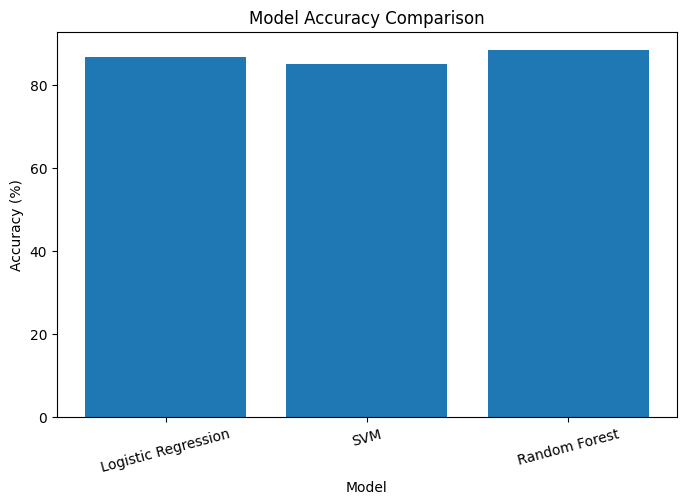

In [ ]:
# STEP 20 — Plot model comparison
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

In [ ]:
# STEP 21 — Find the best model
best_model_name = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

best_accuracy = results["Accuracy"].max()

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy * 100, "%")

Best Model: Random Forest
Best Accuracy: 88.52459016393442 %


thalach     0.135404
cp          0.127163
thal        0.122940
ca          0.100811
age         0.091327
oldpeak     0.089358
chol        0.088681
trestbps    0.080716
exang       0.050730
slope       0.046626
sex         0.035947
restecg     0.018389
fbs         0.011908
dtype: float64


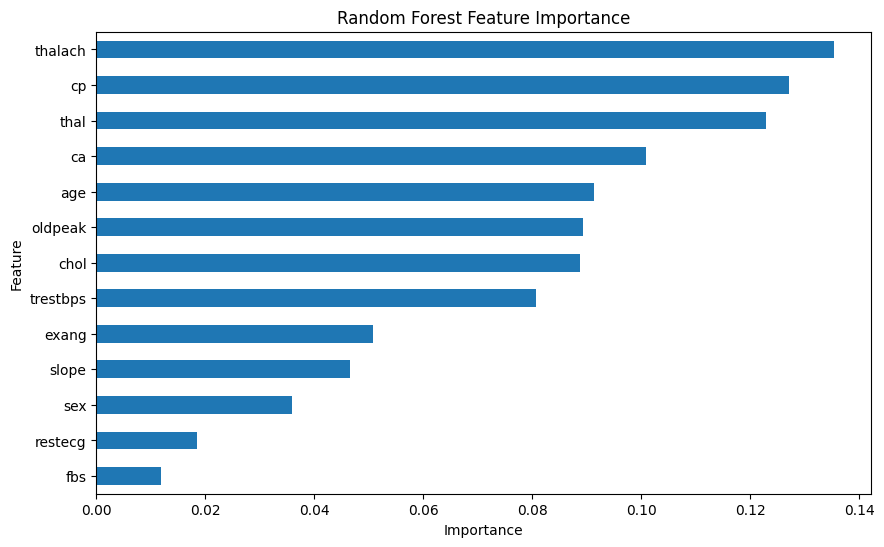

In [ ]:
# Step-22 Feature importance
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)
# plot
plt.figure(figsize=(10, 6))

importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

In [ ]:
# Step 24 — Make a prediction for one sample
sample = X_test.iloc[0:1]

prediction = rf_model.predict(sample)

print("Predicted class:", prediction[0])

if prediction[0] == 0:
    print("Model prediction: No disease")
else:
    print("Model prediction: Disease")

Predicted class: 0
Model prediction: No disease


 Final conclusion :
In this project, machine-learning classification techniques were applied to the UCI Heart Disease dataset. The dataset contains patient-related medical features such as age, chest pain type, blood pressure, cholesterol, maximum heart rate, and other clinical measurements. The data was cleaned, split into training and testing sets, and standardized where appropriate. Logistic Regression, Support Vector Machine, and Random Forest classifiers were trained and evaluated. Their performance was compared using accuracy, confusion matrices, and classification reports. The model with the highest test accuracy was selected as the best-performing model for this experiment.